# DSCI 552 Homework 2

**Name:** Shirley Feng

**GitHub Username:** snowxxxue

**USC ID:** 7145149057

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import statsmodels.formula.api as smf

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import MinMaxScaler

In [7]:
df = pd.read_excel("CCPP/Folds5x2_pp.xlsx")
df.head()

,AT,V,AP,RH,PE
0,14.96,41.76,1024.07,73.17,463.26
1,25.18,62.96,1020.04,59.08,444.37
2,5.11,39.40,1012.16,92.14,488.56
3,20.86,57.32,1010.24,76.64,446.48
4,10.82,37.50,1009.23,96.62,473.90


## Question 1(b)(i)

How many rows are in this data set? How many columns? What do the rows and columns represent?

In [8]:
# Dataset dimensions
print("Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Dataset information
print("\nDataset Info:")
df.info()

Shape: (9568, 5)

Columns:
Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='str')

Dataset Info:
<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


### Answer

- The dataset contains **9,568 rows** and **5 columns**.
- Each row represents one hourly observation collected from the Combined Cycle Power Plant.
- The five columns represent:
  - **AT**: Ambient Temperature
  - **V**: Exhaust Vacuum
  - **AP**: Ambient Pressure
  - **RH**: Relative Humidity
  - **PE**: Net hourly electrical energy output (response variable)

## Question 1(b)(ii)

Make pairwise scatterplots of all the variables in the dataset including the predictors with the dependent variable. Describe your findings.

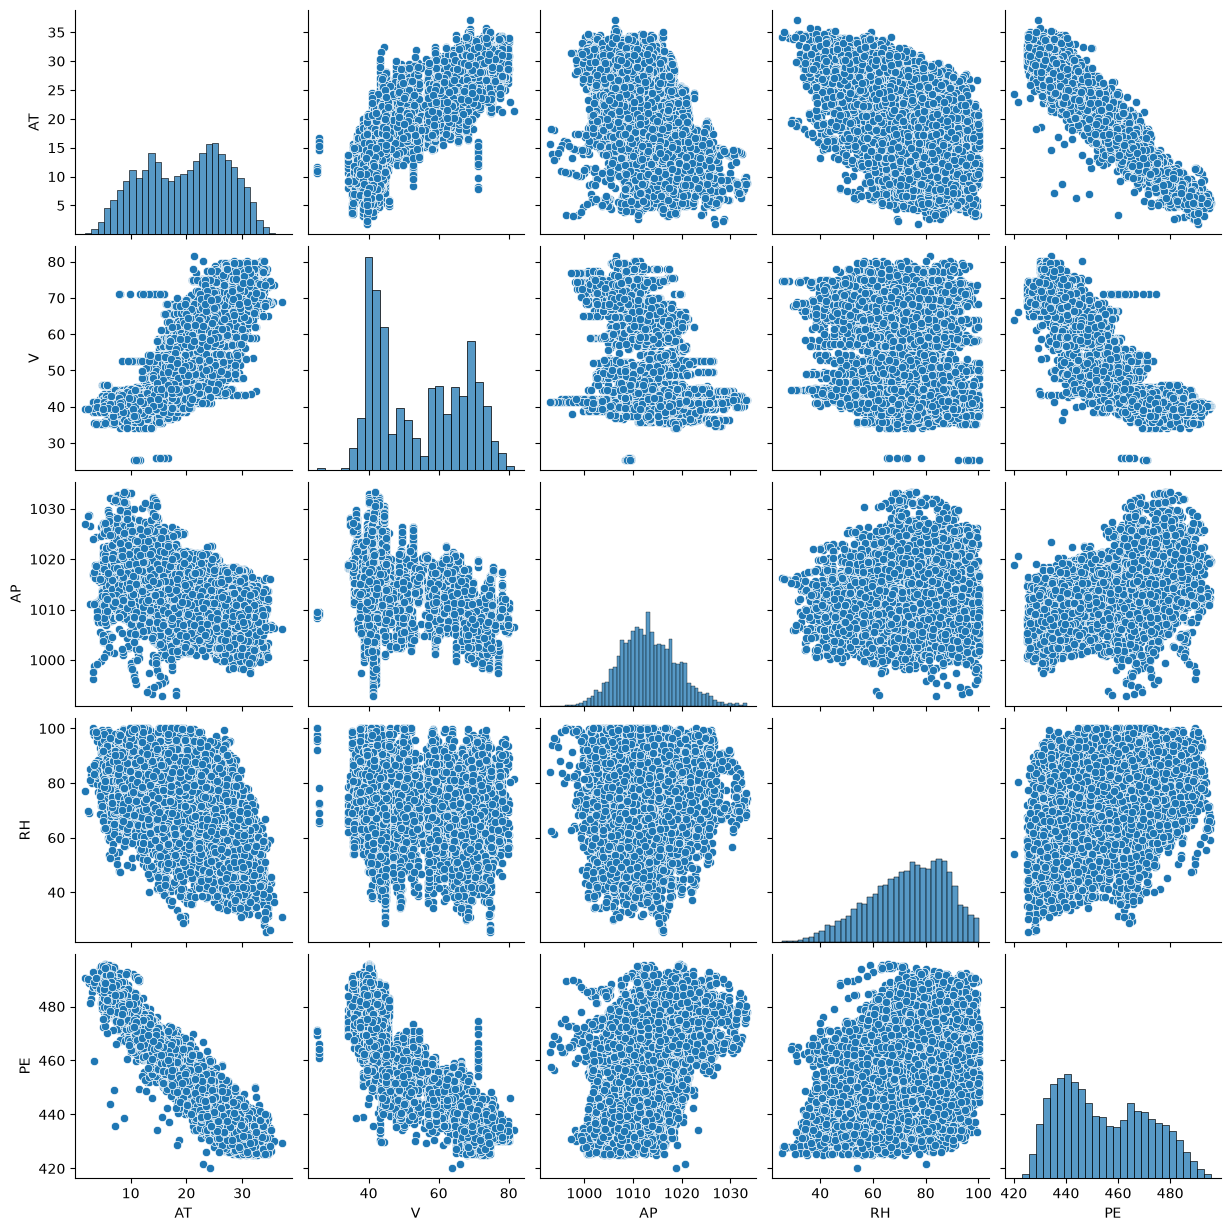

In [9]:
sns.pairplot(df)

plt.show()

### Answer

From the pairwise scatterplots, several relationships can be observed:

- **AT (Ambient Temperature)** has a strong negative relationship with **PE**. As the ambient temperature increases, the net electrical energy output tends to decrease.
- **V (Exhaust Vacuum)** also shows a negative relationship with **PE**, although the relationship is weaker than that of AT.
- **AP (Ambient Pressure)** has a weak positive relationship with **PE**.
- **RH (Relative Humidity)** appears to have a weak to moderate positive relationship with **PE**.
- Some predictors are correlated with each other. For example, **AT** and **V** show a noticeable positive association, while **AT** and **RH** show a negative association.
- No obvious extreme outliers are observed in the scatterplots, although a few isolated observations are present.

## Question 1(b)(iii)

Calculate the mean, median, range, first quartile (Q1), third quartile (Q3), and interquartile range (IQR) for each variable.

In [10]:
summary = pd.DataFrame({
    "Mean": df.mean(),
    "Median": df.median(),
    "Range": df.max() - df.min(),
    "Q1": df.quantile(0.25),
    "Q3": df.quantile(0.75)
})

summary["IQR"] = summary["Q3"] - summary["Q1"]

summary

,Mean,Median,Range,Q1,Q3,IQR
AT,19.651231,20.345,35.30,13.5100,25.72,12.2100
V,54.305804,52.080,56.20,41.7400,66.54,24.8000
AP,1013.259078,1012.940,40.41,1009.1000,1017.26,8.1600
RH,73.308978,74.975,74.60,63.3275,84.83,21.5025
PE,454.365009,451.550,75.50,439.7500,468.43,28.6800


### Answer

The table above summarizes the descriptive statistics of all variables, including the mean, median, range, first quartile (Q1), third quartile (Q3), and interquartile range (IQR).

## Question 1(c)

### Simple Linear Regression: PE ~ AT

In [11]:
model_AT = smf.ols("PE ~ AT", data=df).fit()

print(model_AT.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.899
Model:                            OLS   Adj. R-squared:                  0.899
Method:                 Least Squares   F-statistic:                 8.510e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:30:40   Log-Likelihood:                -29756.
No. Observations:                9568   AIC:                         5.952e+04
Df Residuals:                    9566   BIC:                         5.953e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    497.0341      0.156   3177.280      0.0

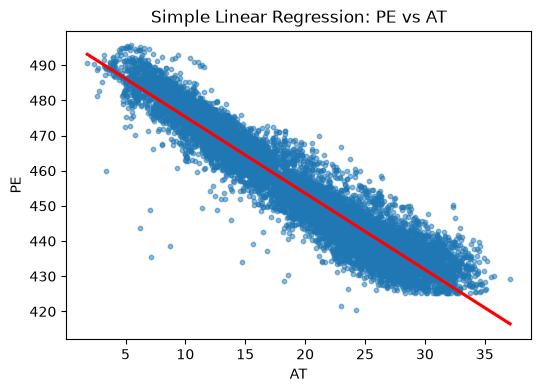

In [12]:
plt.figure(figsize=(6,4))

sns.regplot(
    x="AT",
    y="PE",
    data=df,
    scatter_kws={"s":10, "alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Simple Linear Regression: PE vs AT")
plt.show()

In [13]:
model_V = smf.ols("PE ~ V", data=df).fit()

print(model_V.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.757
Model:                            OLS   Adj. R-squared:                  0.756
Method:                 Least Squares   F-statistic:                 2.972e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:30:40   Log-Likelihood:                -33963.
No. Observations:                9568   AIC:                         6.793e+04
Df Residuals:                    9566   BIC:                         6.794e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    517.8015      0.378   1370.218      0.0

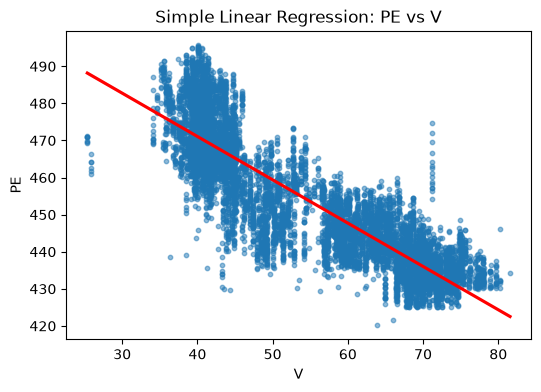

In [14]:
plt.figure(figsize=(6,4))

sns.regplot(
    x="V",
    y="PE",
    data=df,
    scatter_kws={"s":10, "alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Simple Linear Regression: PE vs V")
plt.show()

In [15]:
model_AP = smf.ols("PE ~ AP", data=df).fit()

print(model_AP.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.269
Model:                            OLS   Adj. R-squared:                  0.269
Method:                 Least Squares   F-statistic:                     3516.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:30:40   Log-Likelihood:                -39224.
No. Observations:                9568   AIC:                         7.845e+04
Df Residuals:                    9566   BIC:                         7.847e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1055.2610     25.459    -41.449      0.0

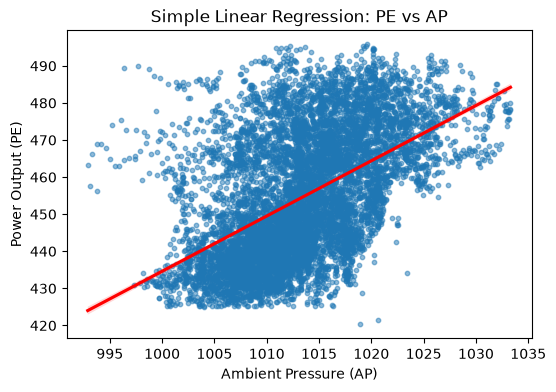

In [16]:
plt.figure(figsize=(6,4))

sns.regplot(
    x="AP",
    y="PE",
    data=df,
    scatter_kws={"s":10, "alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Simple Linear Regression: PE vs AP")
plt.xlabel("Ambient Pressure (AP)")
plt.ylabel("Power Output (PE)")

plt.show()

In [17]:
model_RH = smf.ols("PE ~ RH", data=df).fit()

print(model_RH.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.152
Model:                            OLS   Adj. R-squared:                  0.152
Method:                 Least Squares   F-statistic:                     1714.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:30:41   Log-Likelihood:                -39933.
No. Observations:                9568   AIC:                         7.987e+04
Df Residuals:                    9566   BIC:                         7.988e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    420.9618      0.823    511.676      0.0

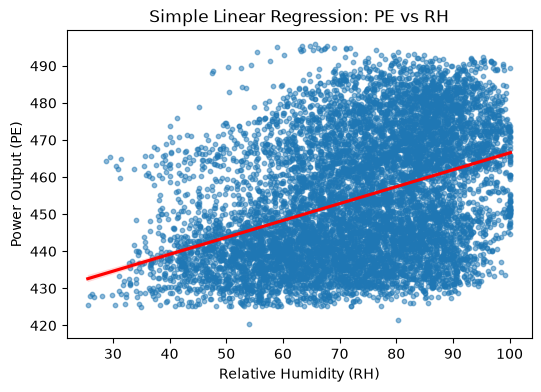

In [18]:
plt.figure(figsize=(6,4))

sns.regplot(
    x="RH",
    y="PE",
    data=df,
    scatter_kws={"s":10, "alpha":0.5},
    line_kws={"color":"red"}
)

plt.title("Simple Linear Regression: PE vs RH")
plt.xlabel("Relative Humidity (RH)")
plt.ylabel("Power Output (PE)")

plt.show()

### Answer

Four simple linear regression models were fitted using each predictor separately.

- **AT** has a strong negative relationship with PE. Its regression coefficient is **-2.1713**, indicating that the predicted power output decreases as ambient temperature increases. This model has the highest explanatory power (**R² = 0.899**).

- **V** also has a negative relationship with PE, with a regression coefficient of **-1.1681** and **R² = 0.757**.

- **AP** has a positive regression coefficient (**1.4899**), indicating a positive association with PE. However, its explanatory power is much lower (**R² = 0.269**).

- **RH** also has a positive relationship with PE, but it explains the least variation among the four models (**R² = 0.152**).

For all four models, the p-values are smaller than 0.05, indicating statistically significant associations between each predictor and the response variable.

The regression plots do not show obvious extreme outliers, although a few isolated observations are present. Therefore, no observations are removed from the dataset.

## Question 1(d)

Fit a multiple linear regression model using all predictors.

In [19]:
model_all = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=df
).fit()

print(model_all.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.929
Model:                            OLS   Adj. R-squared:                  0.929
Method:                 Least Squares   F-statistic:                 3.114e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:30:41   Log-Likelihood:                -28088.
No. Observations:                9568   AIC:                         5.619e+04
Df Residuals:                    9563   BIC:                         5.622e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    454.6093      9.749     46.634      0.0

### Answer

A multiple linear regression model was fitted using all four predictors (AT, V, AP, and RH).

The model achieves an **R² of 0.929**, which is higher than any of the simple linear regression models, indicating that using all predictors together improves the prediction accuracy.

All predictors have **p-values smaller than 0.05**, so we reject the null hypothesis \(H_0:\beta_j=0\) for all four predictors. Therefore, each predictor has a statistically significant association with the response variable after controlling for the other variables.

The regression coefficients indicate that:

- AT has a negative effect on PE.
- V has a negative effect on PE.
- AP has a positive effect on PE.
- RH has a negative effect on PE.

Compared with the simple linear regression models, the coefficient of RH changes from positive to negative after adjusting for the other predictors, suggesting that the predictors are correlated with one another.

## Question 1(e)

Compare the results from Question 1(c) and Question 1(d).

Create a plot displaying the univariate regression coefficients from Question 1(c) on the x-axis and the multiple regression coefficients from Question 1(d) on the y-axis.

In [20]:
simple_coef = [
    model_AT.params["AT"],
    model_V.params["V"],
    model_AP.params["AP"],
    model_RH.params["RH"]
]

multiple_coef = [
    model_all.params["AT"],
    model_all.params["V"],
    model_all.params["AP"],
    model_all.params["RH"]
]

predictors = ["AT", "V", "AP", "RH"]

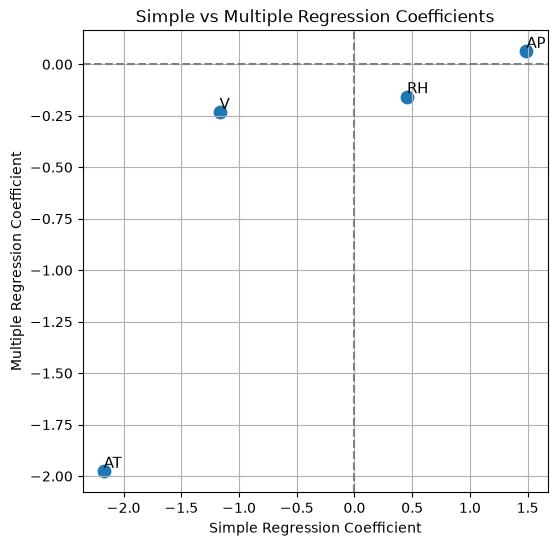

In [21]:
plt.figure(figsize=(6,6))

plt.scatter(simple_coef, multiple_coef, s=80)

for i, predictor in enumerate(predictors):
    plt.text(
        simple_coef[i],
        multiple_coef[i],
        predictor,
        fontsize=11,
        ha="left",
        va="bottom"
    )

plt.axhline(0, color="gray", linestyle="--")
plt.axvline(0, color="gray", linestyle="--")

plt.xlabel("Simple Regression Coefficient")
plt.ylabel("Multiple Regression Coefficient")
plt.title("Simple vs Multiple Regression Coefficients")

plt.grid(True)

plt.show()

### Answer

The scatter plot compares the coefficients obtained from the simple linear regression models and the multiple linear regression model.

- AT and V remain negative in both models, although their magnitudes decrease in the multiple regression model.
- AP remains positive in both models, but its coefficient becomes much smaller in the multiple regression model.
- RH changes from a positive coefficient in the simple regression model to a negative coefficient in the multiple regression model.
- This change suggests that RH is correlated with the other predictors, and the multiple regression model estimates the effect of each predictor while controlling for the others.

## Question 1(f)

Is there evidence of nonlinear association between any of the predictors and the response?

For each predictor, fit a cubic polynomial regression model and examine whether the quadratic and cubic terms are statistically significant.

In [22]:
model_AT_poly = smf.ols(
    "PE ~ AT + I(AT**2) + I(AT**3)",
    data=df
).fit()

print(model_AT_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.912
Model:                            OLS   Adj. R-squared:                  0.912
Method:                 Least Squares   F-statistic:                 3.299e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:30:41   Log-Likelihood:                -29101.
No. Observations:                9568   AIC:                         5.821e+04
Df Residuals:                    9564   BIC:                         5.824e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    492.7281      0.673    732.248      0.0

In [23]:
model_V_poly = smf.ols(
    "PE ~ V + I(V**2) + I(V**3)",
    data=df
).fit()

print(model_V_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.775
Model:                            OLS   Adj. R-squared:                  0.775
Method:                 Least Squares   F-statistic:                 1.098e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:30:41   Log-Likelihood:                -33585.
No. Observations:                9568   AIC:                         6.718e+04
Df Residuals:                    9564   BIC:                         6.721e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    554.1468      9.151     60.557      0.0

In [24]:
model_AP_poly = smf.ols(
    "PE ~ AP + I(AP**2) + I(AP**3)",
    data=df
).fit()

print(model_AP_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.275
Model:                            OLS   Adj. R-squared:                  0.275
Method:                 Least Squares   F-statistic:                     1813.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:30:41   Log-Likelihood:                -39184.
No. Observations:                9568   AIC:                         7.837e+04
Df Residuals:                    9565   BIC:                         7.840e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.0747      0.009      8.415      0.0

In [25]:
model_RH_poly = smf.ols(
    "PE ~ RH + I(RH**2) + I(RH**3)",
    data=df
).fit()

print(model_RH_poly.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.154
Model:                            OLS   Adj. R-squared:                  0.153
Method:                 Least Squares   F-statistic:                     579.2
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:30:41   Log-Likelihood:                -39923.
No. Observations:                9568   AIC:                         7.985e+04
Df Residuals:                    9564   BIC:                         7.988e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    468.4135     10.545     44.422      0.0

### Answer

To investigate nonlinear relationships, cubic polynomial regression models were fitted for each predictor.

- **AT:** Both the quadratic and cubic terms are statistically significant (p < 0.05), indicating a nonlinear relationship with PE.
- **V:** The quadratic term is not statistically significant (p = 0.768), while the cubic term is statistically significant (p = 0.014). This suggests evidence of a nonlinear relationship.
- **AP:** Both the quadratic and cubic terms are statistically significant, indicating a nonlinear relationship with PE.
- **RH:** Both the quadratic and cubic terms are statistically significant, indicating a nonlinear relationship with PE.

Overall, there is evidence of nonlinear association between each predictor and the response variable. However, the nonlinear effect for **V** is weaker because only the cubic term is statistically significant.

## Question 1(g)

Is there evidence of association of interactions of predictors with the response?

Fit a multiple linear regression model including all pairwise interaction terms and determine which interaction terms are statistically significant.

In [26]:
model_interaction = smf.ols(
    "PE ~ (AT + V + AP + RH)**2",
    data=df
).fit()

print(model_interaction.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.936
Model:                            OLS   Adj. R-squared:                  0.936
Method:                 Least Squares   F-statistic:                 1.405e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:30:41   Log-Likelihood:                -27548.
No. Observations:                9568   AIC:                         5.512e+04
Df Residuals:                    9557   BIC:                         5.520e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    685.7825     78.640      8.721      0.0

In [27]:
interaction_pvalues = model_interaction.pvalues.filter(
    regex=":"
)

interaction_pvalues

AT:V     3.333358e-117
AT:AP     4.520509e-01
AT:RH     1.216944e-10
V:AP      2.877026e-07
V:RH      8.619366e-02
AP:RH     3.360557e-02
dtype: float64

### Answer

A multiple linear regression model including all pairwise interaction terms was fitted.

Among the six interaction terms:

- **AT × V** is statistically significant (p < 0.05).
- **AT × RH** is statistically significant (p < 0.05).
- **V × AP** is statistically significant (p < 0.05).
- **AP × RH** is statistically significant (p < 0.05).

However,

- **AT × AP** is not statistically significant (p = 0.452).
- **V × RH** is not statistically significant (p = 0.086).

Therefore, several interaction terms have statistically significant associations with the response variable, suggesting that interaction effects should be considered in the regression model.

## Question 1(h)

Train a multiple linear regression model using a randomly selected 70% training set.

Then fit another regression model including interaction terms and quadratic nonlinearities, remove insignificant variables using p-values, and compare the train and test MSEs.

In [28]:
train_df, test_df = train_test_split(
    df,
    test_size=0.3,
    random_state=1
)

In [29]:
baseline_model = smf.ols(
    "PE ~ AT + V + AP + RH",
    data=train_df
).fit()

print(baseline_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.928
Model:                            OLS   Adj. R-squared:                  0.928
Method:                 Least Squares   F-statistic:                 2.167e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:30:41   Log-Likelihood:                -19660.
No. Observations:                6697   AIC:                         3.933e+04
Df Residuals:                    6692   BIC:                         3.936e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    458.3988     11.562     39.649      0.0

In [30]:
train_pred = baseline_model.predict(train_df)
test_pred = baseline_model.predict(test_df)

train_mse = mean_squared_error(
    train_df["PE"],
    train_pred
)

test_mse = mean_squared_error(
    test_df["PE"],
    test_pred
)

print("Baseline Model")
print("Train MSE:", train_mse)
print("Test MSE :", test_mse)

Baseline Model
Train MSE: 20.766119761450952
Test MSE : 20.77747810688431


In [31]:
full_model = smf.ols(
    """
    PE ~ (AT + V + AP + RH)**2
    + I(AT**2)
    + I(V**2)
    + I(AP**2)
    + I(RH**2)
    """,
    data=train_df
).fit()

print(full_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.938
Method:                 Least Squares   F-statistic:                     7181.
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:30:41   Log-Likelihood:                -19192.
No. Observations:                6697   AIC:                         3.841e+04
Df Residuals:                    6682   BIC:                         3.852e+04
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -8171.8080   1416.708     -5.768      0.0

In [32]:
improved_model = smf.ols(
    """
    PE ~
    AT + V + AP + RH
    + AT:V
    + AT:RH
    + AP:RH
    + I(AT**2)
    + I(AP**2)
    + I(RH**2)
    """,
    data=train_df
).fit()

print(improved_model.summary())

                            OLS Regression Results                            
Dep. Variable:                     PE   R-squared:                       0.938
Model:                            OLS   Adj. R-squared:                  0.937
Method:                 Least Squares   F-statistic:                 1.004e+04
Date:                Fri, 25 Sep 2026   Prob (F-statistic):               0.00
Time:                        18:30:41   Log-Likelihood:                -19198.
No. Observations:                6697   AIC:                         3.842e+04
Df Residuals:                    6686   BIC:                         3.849e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -1.052e+04   1079.936     -9.738      0.0

In [33]:
train_pred_improved = improved_model.predict(train_df)
test_pred_improved = improved_model.predict(test_df)

train_mse_improved = mean_squared_error(
    train_df["PE"],
    train_pred_improved
)

test_mse_improved = mean_squared_error(
    test_df["PE"],
    test_pred_improved
)

print("Improved Model")
print("Train MSE:", train_mse_improved)
print("Test MSE :", test_mse_improved)

Improved Model
Train MSE: 18.09323565111272
Test MSE : 18.263588112319812


In [34]:
comparison = pd.DataFrame({
    "Model": ["Baseline", "Improved"],
    "Train MSE": [train_mse, train_mse_improved],
    "Test MSE": [test_mse, test_mse_improved]
})

comparison

,Model,Train MSE,Test MSE
0,Baseline,20.766120,20.777478
1,Improved,18.093236,18.263588


### Answer

The dataset was randomly split into 70% training data and 30% testing data.

Two regression models were compared:

1. **Baseline Model:** Multiple linear regression using the four predictors (AT, V, AP, and RH).
2. **Improved Model:** Multiple linear regression including interaction terms and quadratic nonlinear terms. Insignificant variables were removed based on their p-values while maintaining the model hierarchy.

The comparison of the prediction performance is shown below:

| Model | Train MSE | Test MSE |
|--------|----------:|---------:|
| Baseline | 20.7661 | 20.7775 |
| Improved | 18.0932 | 18.2636 |

The improved model achieves lower training and testing mean squared errors than the baseline model. Therefore, adding significant interaction terms and nonlinear terms improves the predictive performance of the regression model.

## Question 1(i)

Perform k-nearest neighbor regression using both raw features and normalized features.

For each case, evaluate k from 1 to 100, plot the training and testing MSE against 1/k, and identify the best value of k.

In [35]:
X_train = train_df[["AT", "V", "AP", "RH"]]
X_test = test_df[["AT", "V", "AP", "RH"]]

y_train = train_df["PE"]
y_test = test_df["PE"]

In [36]:
raw_train_mse = []
raw_test_mse = []

for k in range(1, 101):

    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train, y_train)

    train_pred = knn.predict(X_train)
    test_pred = knn.predict(X_test)

    raw_train_mse.append(
        mean_squared_error(y_train, train_pred)
    )

    raw_test_mse.append(
        mean_squared_error(y_test, test_pred)
    )

In [37]:
best_k_raw = raw_test_mse.index(min(raw_test_mse)) + 1

print("Best k (Raw Features):", best_k_raw)
print("Lowest Test MSE:", min(raw_test_mse))

Best k (Raw Features): 5
Lowest Test MSE: 15.704821203761764


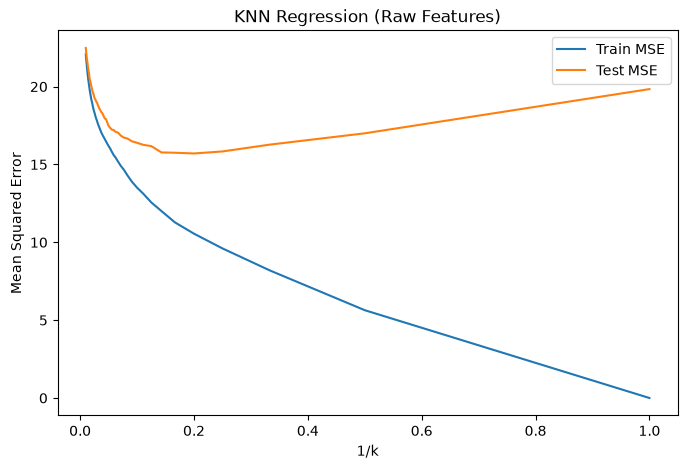

In [38]:
plt.figure(figsize=(8,5))

plt.plot(
    [1/k for k in range(1,101)],
    raw_train_mse,
    label="Train MSE"
)

plt.plot(
    [1/k for k in range(1,101)],
    raw_test_mse,
    label="Test MSE"
)

plt.xlabel("1/k")
plt.ylabel("Mean Squared Error")
plt.title("KNN Regression (Raw Features)")

plt.legend()

plt.show()

In [39]:
scaler = MinMaxScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [40]:
scaled_train_mse = []
scaled_test_mse = []

for k in range(1,101):

    knn = KNeighborsRegressor(n_neighbors=k)

    knn.fit(X_train_scaled, y_train)

    train_pred = knn.predict(X_train_scaled)
    test_pred = knn.predict(X_test_scaled)

    scaled_train_mse.append(
        mean_squared_error(y_train, train_pred)
    )

    scaled_test_mse.append(
        mean_squared_error(y_test, test_pred)
    )

In [41]:
best_k_scaled = scaled_test_mse.index(min(scaled_test_mse)) + 1

print("Best k (Normalized Features):", best_k_scaled)
print("Lowest Test MSE:", min(scaled_test_mse))

Best k (Normalized Features): 5
Lowest Test MSE: 14.030553676071062


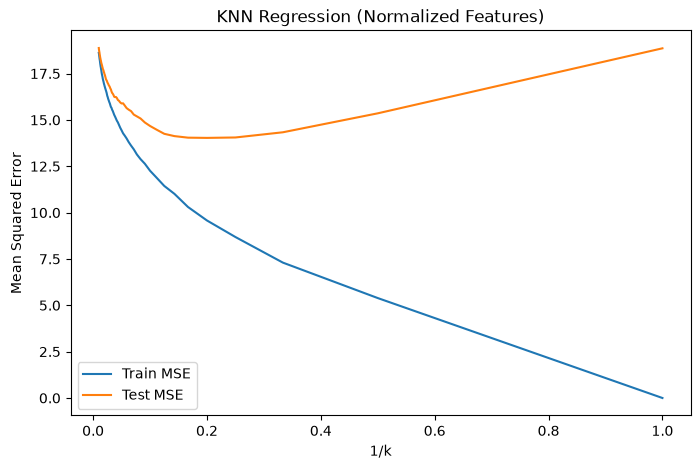

In [42]:
plt.figure(figsize=(8,5))

plt.plot(
    [1/k for k in range(1,101)],
    scaled_train_mse,
    label="Train MSE"
)

plt.plot(
    [1/k for k in range(1,101)],
    scaled_test_mse,
    label="Test MSE"
)

plt.xlabel("1/k")
plt.ylabel("Mean Squared Error")
plt.title("KNN Regression (Normalized Features)")

plt.legend()

plt.show()

### Answer

KNN regression was performed using both raw features and normalized features for values of \(k\) from 1 to 100.

| Feature Type | Best k | Lowest Test MSE |
|--------------|-------:|----------------:|
| Raw Features | 5 | 15.7048 |
| Normalized Features | 5 | 14.0306 |

The training MSE increases as \(k\) increases, while the test MSE first decreases and then increases. Small values of \(k\) tend to overfit the training data, whereas very large values of \(k\) lead to underfitting.

The normalized features produce a lower test MSE than the raw features because KNN is a distance-based algorithm and normalization allows all predictors to contribute equally to the distance calculation.

## Question 1(j)

Compare the results of KNN regression with the linear regression model that has the smallest test error.

### Answer

The best linear regression model is the improved regression model from Question 1(h), which achieved a Test MSE of **18.2636**.

The best KNN regression model used normalized features with **k = 5** and achieved a Test MSE of **14.0306**.

Since the KNN model has a lower Test MSE than the best linear regression model, it provides better predictive performance on this dataset. This suggests that KNN captures nonlinear relationships in the data more effectively than the linear regression model.